# 04 — Model Comparison

This notebook compares multiple machine learning models for Parkinson’s Disease detection using cleaned MDVP voice features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "processed" / "pd_cleaned.csv"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Data path: ..\data\processed\pd_cleaned.csv
Exists: True


In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "status"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Dataset shape: (224, 17)
Feature shape: (224, 16)
Target distribution:
status
1    184
0     40
Name: count, dtype: int64


## Data Splitting Strategy

The dataset was split into training (80%) and testing (20%) sets using stratified sampling to preserve class distribution.

Given the relatively small dataset size (~200 samples), a single train-test split is not sufficient for reliable evaluation. Therefore, cross-validation is also applied in later steps to assess model generalization more robustly.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (179, 16)
Test shape: (45, 16)

Train distribution:
status
1    0.821
0    0.179
Name: proportion, dtype: float64

Test distribution:
status
1    0.822
0    0.178
Name: proportion, dtype: float64


## Model Selection Rationale

A diverse set of models was selected to capture different learning paradigms:

- Logistic Regression: linear baseline model
- SVM: kernel-based classifier for non-linear decision boundaries
- Random Forest: ensemble bagging method
- Gradient Boosting: boosting-based ensemble model
- XGBoost, LightGBM, CatBoost: modern gradient boosting algorithms optimized for tabular data

This combination allows a comprehensive comparison between classical and modern machine learning approaches.

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVM (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ]),

    "LightGBM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42,
            verbose=-1
        ))
    ]),

    "CatBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", CatBoostClassifier(
            iterations=100,
            depth=3,
            learning_rate=0.1,
            verbose=0,
            random_state=42
        ))
    ])
}

list(models.keys())

['Logistic Regression',
 'SVM (RBF Kernel)',
 'Random Forest',
 'Gradient Boosting',
 'XGBoost',
 'LightGBM',
 'CatBoost']

## Test Set Evaluation

Models were first evaluated on the held-out test set using multiple metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matthews Correlation Coefficient (MCC)

Because the dataset is imbalanced, F1-score, ROC-AUC, and MCC are considered more reliable indicators than accuracy alone.

In [6]:
test_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "mcc": matthews_corrcoef(y_test, y_pred)
    }
    
    test_results.append(metrics)

test_results_df = pd.DataFrame(test_results)
test_results_df

,model,accuracy,precision,recall,f1_score,roc_auc,mcc
0,Logistic Regression,0.800000,0.937500,0.810811,0.869565,0.878378,0.473059
1,SVM (RBF Kernel),0.755556,0.933333,0.756757,0.835821,0.915541,0.410997
2,Random Forest,0.888889,0.900000,0.972973,0.935065,0.915541,0.575396
3,Gradient Boosting,0.955556,0.948718,1.000000,0.973684,0.979730,0.843527
4,XGBoost,0.933333,0.925000,1.000000,0.961039,0.935811,0.760345
5,LightGBM,0.933333,0.925000,1.000000,0.961039,0.952703,0.760345
6,CatBoost,0.911111,0.902439,1.000000,0.948718,0.932432,0.671729


In [7]:
test_results_df.to_csv(
    METRICS_DIR / "model_comparison_test_results.csv",
    index=False
)

print("Saved:", METRICS_DIR / "model_comparison_test_results.csv")

Saved: ..\results\metrics\model_comparison_test_results.csv


In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## Cross-Validation Analysis

To obtain a more reliable estimate of model performance, 5-fold Stratified Cross-Validation was applied.

Stratification ensures that each fold preserves the class distribution.

The mean and standard deviation across folds provide:
- Mean: expected generalization performance
- Standard deviation: stability of the model

Cross-validation results are prioritized over single test results when selecting the best model.

In [9]:
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_precision_std": scores["test_precision"].std(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_recall_std": scores["test_recall"].std(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_f1_std": scores["test_f1"].std(),
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.781212,0.091588,0.948140,0.034722,0.777027,0.110282,0.849516,0.071972,0.868788,0.080130
1,SVM (RBF Kernel),0.758788,0.095071,0.935407,0.041246,0.760661,0.118135,0.833328,0.076338,0.861318,0.080892
2,Random Forest,0.870404,0.026670,0.871213,0.021707,0.989189,0.021622,0.926182,0.015039,0.861852,0.094854
3,Gradient Boosting,0.870202,0.039929,0.889539,0.025625,0.961712,0.028275,0.924039,0.023483,0.863645,0.068721
4,XGBoost,0.901616,0.030874,0.901404,0.024857,0.989189,0.021622,0.942985,0.017676,0.903397,0.063650
5,LightGBM,0.888081,0.043453,0.899487,0.027405,0.972673,0.024515,0.934586,0.025183,0.906550,0.077419
6,CatBoost,0.888182,0.025641,0.891707,0.019056,0.983634,0.013366,0.935331,0.014471,0.874343,0.089623


In [10]:
cv_results_df.to_csv(
    METRICS_DIR / "model_comparison_cv_results.csv",
    index=False
)

print("Saved:", METRICS_DIR / "model_comparison_cv_results.csv")

Saved: ..\results\metrics\model_comparison_cv_results.csv


In [11]:
final_comparison = test_results_df.merge(
    cv_results_df,
    on="model",
    how="left"
)

final_comparison = final_comparison.sort_values(
    by="cv_f1_mean",
    ascending=False
)

final_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,mcc,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
4,XGBoost,0.933333,0.925000,1.000000,0.961039,0.935811,0.760345,0.901616,0.030874,0.901404,0.024857,0.989189,0.021622,0.942985,0.017676,0.903397,0.063650
6,CatBoost,0.911111,0.902439,1.000000,0.948718,0.932432,0.671729,0.888182,0.025641,0.891707,0.019056,0.983634,0.013366,0.935331,0.014471,0.874343,0.089623
5,LightGBM,0.933333,0.925000,1.000000,0.961039,0.952703,0.760345,0.888081,0.043453,0.899487,0.027405,0.972673,0.024515,0.934586,0.025183,0.906550,0.077419
2,Random Forest,0.888889,0.900000,0.972973,0.935065,0.915541,0.575396,0.870404,0.026670,0.871213,0.021707,0.989189,0.021622,0.926182,0.015039,0.861852,0.094854
3,Gradient Boosting,0.955556,0.948718,1.000000,0.973684,0.979730,0.843527,0.870202,0.039929,0.889539,0.025625,0.961712,0.028275,0.924039,0.023483,0.863645,0.068721
0,Logistic Regression,0.800000,0.937500,0.810811,0.869565,0.878378,0.473059,0.781212,0.091588,0.948140,0.034722,0.777027,0.110282,0.849516,0.071972,0.868788,0.080130
1,SVM (RBF Kernel),0.755556,0.933333,0.756757,0.835821,0.915541,0.410997,0.758788,0.095071,0.935407,0.041246,0.760661,0.118135,0.833328,0.076338,0.861318,0.080892


## Model Comparison Summary

The final comparison combines both test set and cross-validation results.

Key observations:

- Gradient Boosting achieved the highest test performance.
- XGBoost demonstrated the most stable cross-validation results.
- Modern boosting models (XGBoost, LightGBM, CatBoost) consistently outperformed classical models.
- Linear and kernel-based models showed lower performance, indicating the presence of non-linear relationships in the data.

This suggests that ensemble boosting methods are particularly effective for this task.

In [12]:
final_comparison.to_csv(
    METRICS_DIR / "final_model_comparison.csv",
    index=False
)

print("Saved:", METRICS_DIR / "final_model_comparison.csv")

Saved: ..\results\metrics\final_model_comparison.csv


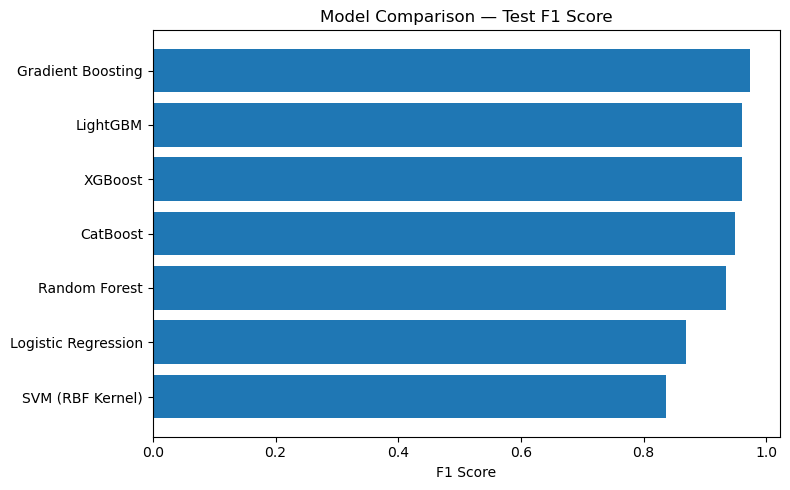

In [13]:
plot_df = test_results_df.sort_values(by="f1_score")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["f1_score"])
plt.title("Model Comparison — Test F1 Score")
plt.xlabel("F1 Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_f1.png", dpi=300)
plt.show()

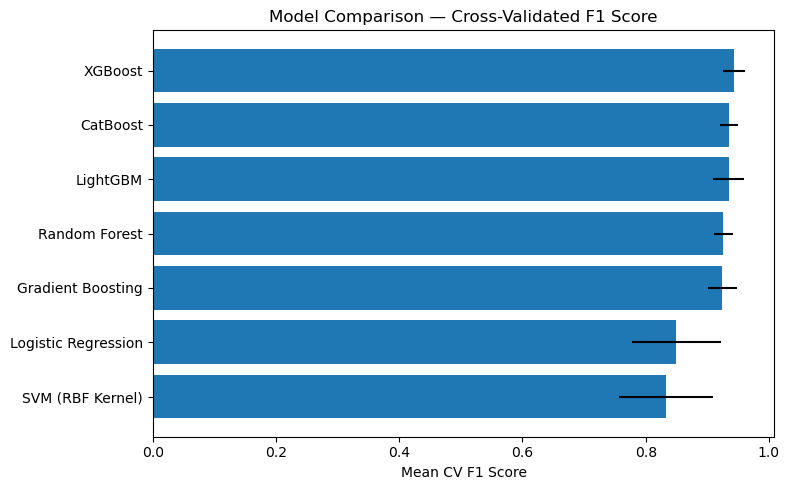

In [14]:
plot_df = cv_results_df.sort_values(by="cv_f1_mean")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["cv_f1_mean"], xerr=plot_df["cv_f1_std"])
plt.title("Model Comparison — Cross-Validated F1 Score")
plt.xlabel("Mean CV F1 Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_cv_f1.png", dpi=300)
plt.show()

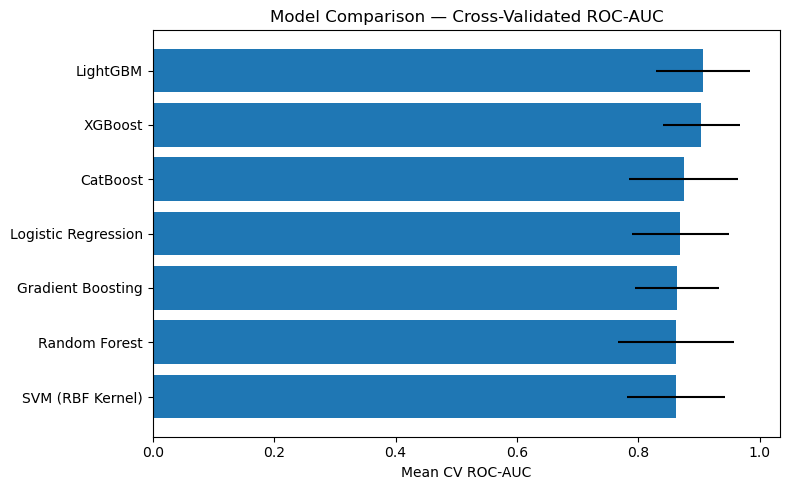

In [15]:
plot_df = cv_results_df.sort_values(by="cv_roc_auc_mean")

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["model"],
    plot_df["cv_roc_auc_mean"],
    xerr=plot_df["cv_roc_auc_std"]
)
plt.title("Model Comparison — Cross-Validated ROC-AUC")
plt.xlabel("Mean CV ROC-AUC")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_cv_roc_auc.png", dpi=300)
plt.show()

In [16]:
best_model_row = final_comparison.iloc[0]

print("Best model based on CV F1:")
print(best_model_row[[
    "model",
    "cv_f1_mean",
    "cv_f1_std",
    "cv_roc_auc_mean",
    "cv_roc_auc_std",
    "mcc"
]])

Best model based on CV F1:
model               XGBoost
cv_f1_mean         0.942985
cv_f1_std          0.017676
cv_roc_auc_mean    0.903397
cv_roc_auc_std      0.06365
mcc                0.760345
Name: 4, dtype: object


In [17]:
readme_table = final_comparison[[
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "mcc",
    "cv_f1_mean",
    "cv_f1_std",
    "cv_roc_auc_mean"
]].copy()

numeric_columns = readme_table.select_dtypes(include=[np.number]).columns
readme_table[numeric_columns] = readme_table[numeric_columns].round(4)

readme_table

,model,accuracy,precision,recall,f1_score,roc_auc,mcc,cv_f1_mean,cv_f1_std,cv_roc_auc_mean
4,XGBoost,0.9333,0.9250,1.0000,0.9610,0.9358,0.7603,0.9430,0.0177,0.9034
6,CatBoost,0.9111,0.9024,1.0000,0.9487,0.9324,0.6717,0.9353,0.0145,0.8743
5,LightGBM,0.9333,0.9250,1.0000,0.9610,0.9527,0.7603,0.9346,0.0252,0.9066
2,Random Forest,0.8889,0.9000,0.9730,0.9351,0.9155,0.5754,0.9262,0.0150,0.8619
3,Gradient Boosting,0.9556,0.9487,1.0000,0.9737,0.9797,0.8435,0.9240,0.0235,0.8636
0,Logistic Regression,0.8000,0.9375,0.8108,0.8696,0.8784,0.4731,0.8495,0.0720,0.8688
1,SVM (RBF Kernel),0.7556,0.9333,0.7568,0.8358,0.9155,0.4110,0.8333,0.0763,0.8613


In [18]:
readme_table.to_csv(
    METRICS_DIR / "readme_model_comparison_table.csv",
    index=False
)

print("Saved:", METRICS_DIR / "readme_model_comparison_table.csv")

Saved: ..\results\metrics\readme_model_comparison_table.csv


## Best Model Selection

The best model is selected based on cross-validation F1-score, as it balances precision and recall for imbalanced data.

Although Gradient Boosting achieved the highest test performance, XGBoost demonstrated slightly more stable cross-validation results.

Therefore:
- Gradient Boosting is considered the best-performing model.
- XGBoost is considered the most robust and stable model.

Both models are strong candidates for further analysis.

## Model Comparison Summary

This notebook compared classical and modern machine learning models for Parkinson’s Disease detection using cleaned MDVP voice features.

The comparison included:
- Logistic Regression
- SVM with RBF kernel
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

Because the dataset is imbalanced, model selection prioritizes:
- F1-score
- ROC-AUC
- Recall
- Matthews Correlation Coefficient

Cross-validation provides a more reliable estimate of model generalization than a single train-test split.